In [1]:
from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch
from core import GeoMEGBenchmark, BenchmarkConfig
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.font_manager import FontProperties

ROOT = Path('C:\\Users\\scx20\\Downloads\\Physics_conditioned_residual_learning_for_source_localization_in_unshielded_scalar_OPM_MEG__a_spherical_conductor_benchmark_with_continuous_off_grid_s')
TABLES = ROOT / 'outputs' / 'tables'
DATA = ROOT / 'outputs' / 'data'
FIGS = ROOT / 'outputs' / 'figures-2'
FIGS.mkdir(parents=True, exist_ok=True)

In [2]:


plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'legend.fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.titlesize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

COL = {
    'geomeg': '#CB7888',
    'centroid': '#E0AB81',
    'grid': '#8AA2C4',
    'raw': '#A18DB0',
    'mne': '#BFC9AD',
    'no_cent': '#496D63',
    'cent_only': '#527A71',
    'no_nuis': '#99BFB2',
    'scores_nuis': '#7D81A4',
    'coords_cent': '#CFC8DA',
    'nuis_only': '#898A7C',
    'truth': '#f8bc3c'
}


def top_cluster(candidates_mm: np.ndarray, split_score: np.ndarray, split_top: np.ndarray, idx: int):
    top = split_top[idx]
    cand = candidates_mm[top]
    sc = split_score[idx][top]
    w = np.exp(sc - sc.max())
    w = w / w.sum()
    cent = (cand * w[:, None]).sum(0)
    return top, cand, sc, w, cent




summary = pd.read_csv(TABLES / 'summary_results.csv')
ablation = pd.read_csv(TABLES / 'ablation_results.csv')
eta = pd.read_csv(TABLES / 'factor_eta_squared.csv')
gimp = pd.read_csv(TABLES / 'feature_group_importance.csv')
stress = pd.read_csv(TABLES / 'stress_test_results.csv')
df_iid = pd.read_csv(TABLES / 'detailed_iid_predictions.csv')
df_ood = pd.read_csv(TABLES / 'detailed_ood_predictions.csv')
cg = pd.read_csv(TABLES / 'cluster_geometry_analysis.csv')
arr = np.load(DATA / 'benchmark_core.npz', allow_pickle=True)

bench = GeoMEGBenchmark(BenchmarkConfig())
sensors_mm = arr['sensors'] * 1000.0
candidates_mm = arr['candidates'] * 1000.0

def draw_3d_arrow(ax, start, end, color='#6fa8dc', alpha=0.8, shaft_width=1, head_length=10, head_radius=2):
    """
    绘制美观 3D 箭头（杆+圆锥尖端）
    start, end: np.array([x,y,z])
    color: 箭头颜色
    alpha: 透明度
    shaft_width: 箭杆线宽
    head_length: 箭头尖长度
    head_radius: 尖端半径
    """
    vec = end - start
    vec_len = np.linalg.norm(vec)
    if vec_len == 0:
        return
    v = vec / vec_len
    shaft_end = end - v * head_length
    # 绘制杆
    ax.plot([start[0], shaft_end[0]],
            [start[1], shaft_end[1]],
            [start[2], shaft_end[2]],
            color=color, alpha=alpha, linewidth=shaft_width)
    
    # 绘制圆锥尖端
    n = 12
    if np.allclose(v, [0,0,1]):
        u1 = np.array([1,0,0])
    else:
        u1 = np.cross(v, [0,0,1])
        u1 /= np.linalg.norm(u1)
    u2 = np.cross(v, u1)
    
    theta = np.linspace(0, 2*np.pi, n)
    circle_pts = [shaft_end + head_radius*np.cos(t)*u1 + head_radius*np.sin(t)*u2 for t in theta]
    verts = [[shaft_end.tolist(), end.tolist(), circle_pts[i].tolist()] for i in range(n)]
    poly = Poly3DCollection(verts, color=color, alpha=alpha)
    ax.add_collection3d(poly)


# ----------------------- 主绘图 -----------------------
fig = plt.figure(figsize=(3.4, 3.2))  # 单栏尺寸
fig.patch.set_facecolor('#ffffff')
gs = GridSpec(1, 1, figure=fig)
ax = fig.add_subplot(gs[0, 0], projection='3d')
ax.set_facecolor('#ffffff')

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 6

# Ambient field 均匀箭头（3x3x3 光束）
start = np.array([0, -40, 110])
end = np.array([0, 40, 10])
n_arrows_side = 3
offsets = np.linspace(-100, 100, n_arrows_side)
for dx in offsets:
    for dy in offsets:
        s = start + np.array([dx, dy, 0])
        e = end + np.array([dx, dy, 0])
        # draw_3d_arrow(ax, s, e, color='#6fa8dc', alpha=0.8, shaft_width=1, head_length=10, head_radius=2)
        ax.quiver(s[0], s[1], s[2], e[0]-s[0], e[1]-s[1], e[2]-s[2], arrow_length_ratio=0.12, color='#6fa8dc', alpha=0.8, linewidth=1)

# Sensors
ax.scatter(sensors_mm[:, 0], sensors_mm[:, 1], sensors_mm[:, 2],
           s=15, alpha=0.6, color='#351c75', label='Sensors', edgecolors='k', linewidth=0.2)

# Candidate shells
for rad, alpha, col in zip([60, 70, 80], [0.6, 0.55, 0.5], ['#e69138', '#ffd966', '#b6d7a8']):
    pts = candidates_mm[np.isclose(np.linalg.norm(candidates_mm, axis=1), rad, atol=1.0)]
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=7, alpha=alpha, color=col, label=f'{rad} mm shell')

# True source
true = arr['iid_truth'][0] * 1000.0
ax.scatter([true[0]], [true[1]], [true[2]], s=60, color=COL['truth'], marker='*',
           label='True source', edgecolors='k', linewidth=0.6)

# Axes labels & limits
ax.set_xlabel('x (mm)', fontsize=6, labelpad=-8)
ax.set_ylabel('y (mm)', fontsize=6, labelpad=-8)
ax.set_zlabel('z (mm)', fontsize=6, labelpad=-8)
ax.set_xlim(-115, 115)
ax.set_ylim(-115, 115)
ax.set_zlim(0, 110)

# 稀疏刻度
ax.set_xticks(np.linspace(-100, 100, 5))
ax.set_yticks(np.linspace(-100, 100, 5))
ax.set_zticks(np.linspace(0, 100, 5))

# Tick labels 和轴距离
ax.tick_params(axis='both', which='major', labelsize=6, pad=0.5)
ax.tick_params(axis='z', which='major', labelsize=6, pad=0.5)

# 视角和网格
ax.view_init(elev=25, azim=-50)
ax.grid(alpha=0.05)

# 图例缩小
ax.legend(loc='upper right', fontsize=5, frameon=True, shadow=False, markerscale=0.7, borderaxespad=0.3)

# 保存
fig.tight_layout()
fig.savefig(FIGS / 'fig1_geometry.pdf', bbox_inches='tight', pad_inches=0.2)
plt.close(fig)

In [3]:
arr = np.load(DATA / 'benchmark_core.npz', allow_pickle=True)
print(arr.files)

['sensors', 'candidates', 'iid_truth', 'iid_score', 'iid_top_idx', 'iid_y', 'iid_mask', 'ood_truth', 'ood_score', 'ood_top_idx', 'ood_y', 'ood_mask', 'iid_centroid', 'iid_grid', 'iid_mne', 'iid_geomeg', 'ood_centroid', 'ood_grid', 'ood_mne', 'ood_geomeg', 'rep_iid', 'rep_ood']


In [4]:
arr

NpzFile 'C:\\Users\\scx20\\Downloads\\Physics_conditioned_residual_learning_for_source_localization_in_unshielded_scalar_OPM_MEG__a_spherical_conductor_benchmark_with_continuous_off_grid_s\\outputs\\data\\benchmark_core.npz' with keys: sensors, candidates, iid_truth, iid_score, iid_top_idx...

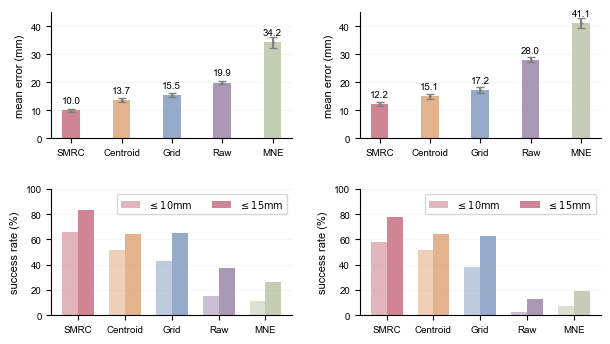

In [5]:
# fig4 main
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False  # 避免负号显示异常
plt.rcParams['font.size'] = 6
arial_font = FontProperties(family='Arial', size=7)

order = ['geomeg','centroid','grid','raw','mne']
fig = plt.figure(figsize=(180/25.4, 100/25.4))
gs = GridSpec(2,2, figure=fig, hspace=0.4, wspace=0.28)
for c, split in enumerate(['IID', 'OOD']):
    sub = summary[summary['split']==split].set_index('method').loc[order].reset_index()
    x = np.arange(len(order))
    means = sub['mean_mm'].to_numpy(); se = sub['sd_mm'].to_numpy()/np.sqrt(sub['n'].to_numpy())
    ax = fig.add_subplot(gs[0,c])
    ax.bar(
        x,
        means,
        width=0.35,   # 控制柱宽，常用 0.4~0.8
        color=[COL[m] for m in order],
        alpha=0.9,
        zorder=2
    )
    
    ax.errorbar(
        x,
        means,
        yerr=1.96*se,
        fmt='o',
        color='gray',
        capsize=3,
        ms=1,
        zorder=3
    )
    ax.set_xticks(x, ['SMRC','Centroid','Grid','Raw','MNE'], rotation=0)
    ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
    # ax.set_title(split); 
    ax.grid(axis='y', alpha=0.1)
    ax.set_ylim(0, max(means)*1.18)
    ax.tick_params(axis='both', labelsize=7)
    for xi, m in zip(x, means):
        ax.text(xi, m+2.5, f'{m:.1f}', ha='center', fontsize=7)
    ax.set_ylim([0,45])


    
    ax2 = fig.add_subplot(gs[1,c])
    width=0.34
    acc10 = sub['acc_10mm'].to_numpy()*100; acc15 = sub['acc_15mm'].to_numpy()*100
    ax2.bar(x-width/2, acc10, width=width, color=[COL[m] for m in order], alpha=0.55, label=r'$\leq 10 \mathrm{mm}$')
    ax2.bar(x+width/2, acc15, width=width, color=[COL[m] for m in order], alpha=0.90, label=r'$\leq 15 \mathrm{mm}$')
    ax2.set_xticks(x, ['SMRC','Centroid','Grid','Raw','MNE'], rotation=0)
    ax2.set_ylabel('success rate (%)', fontsize=8, fontname='Arial')
    ax2.tick_params(axis='both', labelsize=7)
    ax2.set_ylim(0,100); 
    ax2.grid(axis='y', alpha=0.1)
    ax2.legend(frameon=True, loc='upper right', prop=arial_font, ncol=2)


fig.savefig(FIGS / 'fig4_main_results.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

In [6]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
def make_3d_compact(ax, pts, elev=22, azim=-55, zoom=1.35):
    pts = np.asarray(pts)

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    ranges = maxs - mins
    centers = (mins + maxs) / 2

    pad = 0.04
    mins = mins - pad * ranges
    maxs = maxs + pad * ranges
    ranges = maxs - mins

    ax.set_xlim(mins[0], maxs[0])
    ax.set_ylim(mins[1], maxs[1])
    ax.set_zlim(mins[2], maxs[2])

    ax.set_box_aspect(
        (ranges[0], ranges[1], ranges[2]),
        zoom=zoom
    )

    ax.view_init(elev=elev, azim=azim)
    ax.set_proj_type('ortho')

    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_zlabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.grid(False)
    ax.set_axis_off()

def add_bottom_colorbar(fig, ax, mappable, width_ratio=0.90, height=0.010, pad=0.010):
    """
    在 ax 底部内部添加一个独立的 horizontal colorbar。
    height 和 pad 是 figure 坐标，不是 axes 坐标。
    """
    fig.canvas.draw()  # 确保 ax.get_position() 是最终位置
    pos = ax.get_position()

    cb_w = pos.width * width_ratio
    cb_h = height
    cb_x = pos.x0 + (pos.width - cb_w) / 2
    cb_y = pos.y0 + pad

    cax = fig.add_axes([cb_x, cb_y, cb_w, cb_h], zorder=50)
    cax.set_facecolor("white")

    cbar = fig.colorbar(mappable, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(labelsize=7, length=2, pad=1)

    # 对 PDF/vector 输出更稳，避免色块和边框视觉错位或白缝
    if hasattr(cbar, "solids") and cbar.solids is not None:
        cbar.solids.set_edgecolor("face")
        cbar.solids.set_rasterized(True)

    cbar.outline.set_linewidth(0.4)

    for label in cbar.ax.get_xticklabels():
        label.set_fontname("Arial")
        label.set_rotation(30)
        label.set_ha("right")

    return cbar

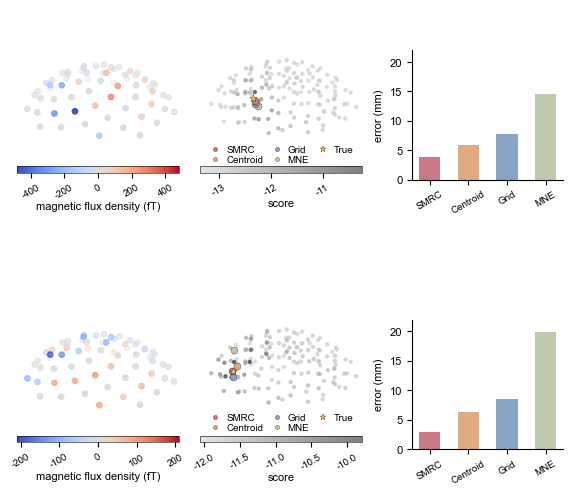

In [7]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap


# =========================
# Helper functions
# =========================

def freeze_inset_axes_for_tight_pdf(fig, axes_to_freeze):
    """
    Freeze inset_axes positions before savefig(..., bbox_inches='tight').

    This avoids PDF/vector backend re-evaluating the inset locator during
    tight-bbox calculation, which can shift colorbars in the saved PDF.
    """
    fig.canvas.draw()

    for ax_inset in axes_to_freeze:
        pos = ax_inset.get_position().frozen()
        ax_inset.set_axes_locator(None)
        ax_inset.set_position(pos)

    fig.canvas.draw()


def style_horizontal_colorbar(cbar, label, tick_formatter=None):
    """
    Apply consistent style to horizontal colorbars.
    """
    if tick_formatter is not None:
        cbar.ax.xaxis.set_major_formatter(tick_formatter)
        cbar.update_ticks()

    cbar.ax.tick_params(labelsize=7)
    cbar.outline.set_linewidth(0.4)
    cbar.solids.set_edgecolor("face")
    cbar.solids.set_linewidth(0)

    cbar.ax.set_xlabel(
        label,
        fontsize=8,
        fontname="Arial",
        labelpad=1
    )
    cbar.ax.xaxis.set_label_position("bottom")

    for tick_label in cbar.ax.get_xticklabels():
        tick_label.set_fontname("Arial")
        tick_label.set_rotation(30)
        tick_label.set_ha("center")


# =========================
# Basic settings
# =========================

MM = 1 / 25.4

legend_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=COL['geomeg'],
        markeredgecolor='k',
        markeredgewidth=0.2,
        markersize=3,
        label='SMRC'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=COL['centroid'],
        markeredgecolor='k',
        markeredgewidth=0.2,
        markersize=3,
        label='Centroid'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=COL['grid'],
        markeredgecolor='k',
        markeredgewidth=0.2,
        markersize=3,
        label='Grid'
    ),
    Line2D(
        [0], [0],
        marker='o',
        color='none',
        markerfacecolor=COL['mne'],
        markeredgecolor='k',
        markeredgewidth=0.2,
        markersize=3,
        label='MNE'
    ),
    Line2D(
        [0], [0],
        marker='*',
        color='none',
        markerfacecolor=COL['truth'],
        markeredgecolor='k',
        markeredgewidth=0.2,
        markersize=5,
        label='True'
    ),
]


# 截取 binary colormap：从 0.2 开始到 1
base_cmap = plt.cm.binary
new_cmap = LinearSegmentedColormap.from_list(
    "binary_gray_min",
    base_cmap(np.linspace(0.2, 1.0, 256))
)


# =========================
# Figure settings
# =========================

rep_iid = 37
rep_ood = 135

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 6

max_rep_iid = int(arr['rep_iid'][0])
max_rep_ood = int(arr['rep_ood'][0])

fig = plt.figure(figsize=(180 * MM, 160 * MM))

gs = GridSpec(
    2, 4,
    figure=fig,
    width_ratios=[1, 1, 0.1, 0.9],
    wspace=0.12,
    hspace=0.25
)

# 用来保存所有 inset colorbar axes，最后统一冻结
cbar_axes = []

examples = [
    (
        'IID',
        rep_iid,
        arr['iid_score'],
        arr['iid_truth'],
        arr['iid_geomeg'],
        arr['iid_centroid'],
        arr['iid_mne'],
        arr['iid_grid'],
        arr['iid_y'],
        arr['iid_mask'],
        arr['iid_top_idx']
    ),
    (
        'OOD',
        rep_ood,
        arr['ood_score'],
        arr['ood_truth'],
        arr['ood_geomeg'],
        arr['ood_centroid'],
        arr['ood_mne'],
        arr['ood_grid'],
        arr['ood_y'],
        arr['ood_mask'],
        arr['ood_top_idx']
    ),
]


# =========================
# Main plotting loop
# =========================

for r, (
    split_name,
    idx,
    score_map,
    truth_arr,
    geomeg_arr,
    cent_arr,
    mne_arr,
    grid_arr,
    y_arr,
    mask_arr,
    top_idx_arr
) in enumerate(examples):

    score = score_map[idx]
    truth = truth_arr[idx] * 1000.0
    geomeg_pred = geomeg_arr[idx] * 1000.0
    centroid_pred = cent_arr[idx] * 1000.0
    mne_pred = mne_arr[idx] * 1000.0
    grid_pred = grid_arr[idx] * 1000.0
    top = top_idx_arr[idx]

    # =========================
    # Right 3D candidate score map
    # =========================

    ax = fig.add_subplot(
        gs[r, 1],
        projection='3d',
        computed_zorder=False
    )

    sc = ax.scatter(
        candidates_mm[:, 0],
        candidates_mm[:, 1],
        candidates_mm[:, 2],
        c=score,
        s=5,
        cmap=new_cmap,
        alpha=0.5,
        zorder=1
    )

    ax.scatter(
        geomeg_pred[0],
        geomeg_pred[1],
        geomeg_pred[2],
        s=25,
        color=COL['geomeg'],
        label='SMRC',
        edgecolor='k',
        linewidth=0.2,
        zorder=105,
        depthshade=False
    )

    ax.scatter(
        centroid_pred[0],
        centroid_pred[1],
        centroid_pred[2],
        s=25,
        color=COL['centroid'],
        label='Centroid',
        edgecolor='k',
        linewidth=0.2,
        zorder=104,
        depthshade=False
    )

    ax.scatter(
        grid_pred[0],
        grid_pred[1],
        grid_pred[2],
        s=25,
        color=COL['grid'],
        label='Grid',
        edgecolor='k',
        linewidth=0.2,
        zorder=103,
        depthshade=False
    )

    ax.scatter(
        mne_pred[0],
        mne_pred[1],
        mne_pred[2],
        s=25,
        color=COL['mne'],
        label='MNE',
        edgecolor='k',
        linewidth=0.2,
        zorder=102,
        depthshade=False
    )

    ax.scatter(
        truth[0],
        truth[1],
        truth[2],
        s=35,
        marker='*',
        color=COL['truth'],
        label='True',
        edgecolor='k',
        linewidth=0.2,
        zorder=130,
        depthshade=False
    )

    make_3d_compact(
        ax,
        np.vstack([
            candidates_mm,
            truth[None, :],
            geomeg_pred[None, :],
            centroid_pred[None, :],
            mne_pred[None, :],
            grid_pred[None, :]
        ]),
        elev=22,
        azim=-55,
        zoom=1.3
    )

    # Colorbar for score map
    cax = inset_axes(
        ax,
        width="96%",
        height="4%",
        loc="lower center",
        borderpad=0.4
    )
    cbar_axes.append(cax)

    cbar = fig.colorbar(
        sc,
        cax=cax,
        orientation="horizontal"
    )

    style_horizontal_colorbar(
        cbar,
        label="score",
        tick_formatter=FuncFormatter(lambda x, pos: f"{x:.1f}")
    )

    # =========================
    # Left 3D sensor map
    # =========================

    ax2 = fig.add_subplot(
        gs[r, 0],
        projection='3d'
    )

    y = y_arr[idx]

    vmax = np.nanmax(np.abs(y[:]))
    vmin = -vmax

    sc2 = ax2.scatter(
        sensors_mm[:, 0],
        sensors_mm[:, 1],
        sensors_mm[:, 2],
        c=y[:],
        s=15,
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax
    )

    ax2.view_init(elev=20, azim=35)

    make_3d_compact(
        ax2,
        sensors_mm,
        elev=22,
        azim=-55,
        zoom=1.3
    )

    # Colorbar for sensor map
    cax2 = inset_axes(
        ax2,
        width="96%",
        height="4%",
        loc="lower center",
        borderpad=0.4
    )
    cbar_axes.append(cax2)

    cbar2 = fig.colorbar(
        sc2,
        cax=cax2,
        orientation="horizontal"
    )

    style_horizontal_colorbar(
        cbar2,
        label="magnetic flux density (fT)"
    )

    # =========================
    # Bar plot
    # =========================

    ax3 = fig.add_subplot(gs[r, 3])

    # 压缩右侧 bar plot 的高度，并在原来的格子里垂直居中
    pos = ax3.get_position()
    shrink = 0.6
    new_h = pos.height * shrink
    new_y = pos.y0 + (pos.height - new_h) / 4

    ax3.set_position([
        pos.x0,
        new_y,
        pos.width,
        new_h
    ])

    errs = {
        'SMRC': np.linalg.norm(geomeg_pred - truth),
        'Centroid': np.linalg.norm(centroid_pred - truth),
        'Grid': np.linalg.norm(grid_pred - truth),
        'MNE': np.linalg.norm(mne_pred - truth),
    }

    names = list(errs.keys())
    vals = list(errs.values())
    colors = [
        COL['geomeg'],
        COL['centroid'],
        COL['grid'],
        COL['mne']
    ]

    ax3.bar(
        names,
        vals,
        color=colors,
        width=0.55
    )
    
    # for i, v in enumerate(vals[::-1]):
    #     ax3.text(i, v+0.5, f'{v:.1f}', va='center', fontsize=7)

    ax3.set_ylabel(
        'error (mm)',
        fontsize=8,
        fontname='Arial'
    )
    ax3.set_xlabel('')

    ax3.tick_params(
        axis='x',
        rotation=30
    )
    ax3.tick_params(
        axis='x',
        labelsize=7
    )
    ax3.set_ylim([0,22])

    for tick_label in ax3.get_xticklabels():
        tick_label.set_fontname('Arial')


# =========================
# Legends
# =========================

leg1 = fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.39, 0.165),
    frameon=False,
    ncol=3,
    handletextpad=0.1,
    columnspacing=0.4,
    labelspacing=0.1,
    borderaxespad=0.0,
    prop={
        "family": "Arial",
        "size": 7
    }
)

leg2 = fig.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.39, 0.59),
    frameon=False,
    ncol=3,
    handletextpad=0.1,
    columnspacing=0.4,
    labelspacing=0.1,
    borderaxespad=0.0,
    prop={
        "family": "Arial",
        "size": 7
    }
)


# =========================
# Critical part for PDF tight export
# =========================

# 先完整绘制一次，让 inset_axes 得到真实位置
fig.canvas.draw()

# 冻结所有 inset colorbar axes 的位置
freeze_inset_axes_for_tight_pdf(fig, cbar_axes)

# 保存 PDF：保留 bbox_inches='tight'
fig.savefig(
    FIGS / 'fig3_examples.pdf',
    bbox_inches='tight',
    pad_inches=0.02,
    bbox_extra_artists=[
        *cbar_axes,
        leg1,
        leg2
    ]
)

plt.show()
plt.close(fig)

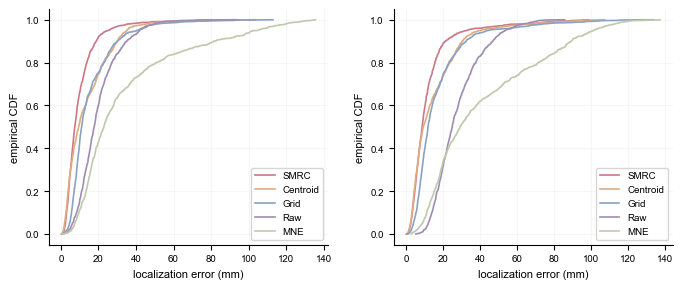

In [8]:

# fig5 cdf
order = ['geomeg','centroid','grid','raw','mne']

MM = 1 / 25.4


# fig3 representative examples

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 15
arial_font = FontProperties(family='Arial', size=7)

fig, axs = plt.subplots(1,2, figsize=(180 * MM, 80 * MM), sharey=True)
for ax, subdf, split in zip(axs, [df_iid, df_ood], ['IID','OOD']):
    for method in order:
        err = np.sort(subdf[f'{method}_err_mm'].to_numpy())
        ax.plot(err, np.linspace(0,1,len(err)), lw=1.2, color=COL[method], label=method)
        ax.tick_params(axis='y', labelleft=True)
        ax.set_xlabel('localization error (mm)', fontsize=8, fontname='Arial')
        ax.set_ylabel('empirical CDF', fontsize=8, fontname='Arial')

    # 坐标轴刻度字号
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(alpha=0.1)
    ax.legend(
        ['SMRC', 'Centroid', 'Grid', 'Raw', 'MNE'],
        frameon=True,
        prop=arial_font
    )


fig.tight_layout()
fig.savefig(FIGS / 'fig5_cdf.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

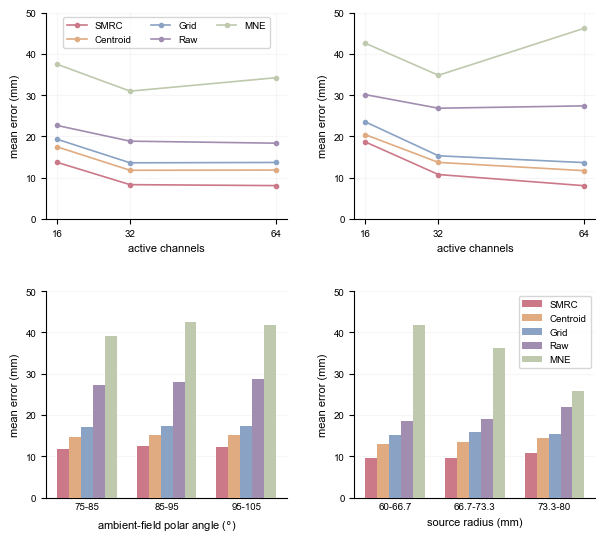

In [9]:
# fig6 robustness
df = pd.concat([df_iid, df_ood], ignore_index=True)
df['polar_bin'] = df['polar_deg'].map(lambda p: '75-85' if p < 85 and p >= 75 else ('85-95' if p < 95 and p >= 85 else ('95-105' if p >=95 else ('0-25' if p <25 else ('25-45' if p<45 else '45-70')))))
df['depth_bin'] = df['source_r'].map(lambda r: '60-66.7' if 1000*r < 66.7 else ('66.7-73.3' if 1000*r < 73.3 else '73.3-80'))
df['count_bin'] = df['count'].astype(int).astype(str)


fig = plt.figure(figsize=(180 * MM, 160 * MM))
gs = GridSpec(2,2, figure=fig, wspace=0.28, hspace=0.35)
for panel, split in enumerate(['IID','OOD']):
    ax = fig.add_subplot(gs[0,panel])
    for method in ['geomeg','centroid','grid','raw', 'mne']:
        rows = [df[(df['split']==split) & (df['count_bin']==count)][f'{method}_err_mm'].mean() for count in ['16','32','64']]
        ax.plot([16,32,64], rows, marker='o', markersize=3, lw=1.2, color=COL[method], label=method)
    # ax.set_title(f'{split}: active channel count'); 
    ax.set_xlabel('active channels', fontsize=8, fontname='Arial'); 
    ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial'); 
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(alpha=0.1)
    ax.set_ylim([0,50])  
    ax.set_xticks([16, 32, 64])
    if panel == 0:
        ax.legend(['SMRC','Centroid','Grid','Raw', 'MNE'], frameon=True, loc='upper center', prop=arial_font, ncol=3)


methods = ['geomeg', 'centroid', 'grid', 'raw', 'mne']
labels = ['SMRC', 'Centroid', 'Grid', 'Raw', 'MNE']

# ---------- OOD: polar_bin ----------
ax = fig.add_subplot(gs[1, 0])

bins = ['75-85', '85-95', '95-105']
x = np.arange(len(bins))
width = 0.15

for i, method in enumerate(methods):
    vals = [
        df[(df['split'] == 'OOD') & (df['polar_bin'] == pb)][f'{method}_err_mm'].mean()
        for pb in bins
    ]
    ax.bar(
        x + (i - 2) * width,
        vals,
        width=width,
        color=COL[method],
        label=labels[i],
        zorder=3
    )

ax.set_xlabel(r'ambient-field polar angle ($\degree$)', fontsize=8, fontname='Arial')
ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=7, fontname='Arial')
ax.tick_params(axis='both', labelsize=7)
ax.grid(axis='y', alpha=0.1, zorder=0)
ax.set_ylim([0, 50])
ax.tick_params(axis='x', length=0)



# ---------- IID: depth_bin ----------
ax = fig.add_subplot(gs[1, 1])

bins = ['60-66.7', '66.7-73.3', '73.3-80']
x = np.arange(len(bins))
width = 0.15

for i, method in enumerate(methods):
    vals = [
        df[(df['split'] == 'IID') & (df['depth_bin'] == db)][f'{method}_err_mm'].mean()
        for db in bins
    ]
    ax.bar(
        x + (i - 2) * width,
        vals,
        width=width,
        color=COL[method],
        label=labels[i],
        zorder=3
    )

ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
ax.set_xlabel('source radius (mm)', fontsize=8, fontname='Arial')
ax.set_xticks(x)
ax.set_xticklabels(bins, fontsize=7, fontname='Arial')
ax.tick_params(axis='both', labelsize=7)
ax.grid(axis='y', alpha=0.1, zorder=0)
ax.set_ylim([0, 50])
ax.legend(frameon=True, loc='upper right', prop=arial_font)
ax.tick_params(axis='x', length=0)


fig.savefig(FIGS / 'fig6_robustness.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

centroid_err_mm coef_0 (slope): 1.3234
centroid_err_mm coef_1 (intercept): -10.3757
centroid_err_mm r value: 0.5956, p value: 2.7276e-192
geomeg_err_mm coef_0 (slope): 0.9833
geomeg_err_mm coef_1 (intercept): -7.2617
geomeg_err_mm r value: 0.5320, p value: 1.4038e-146


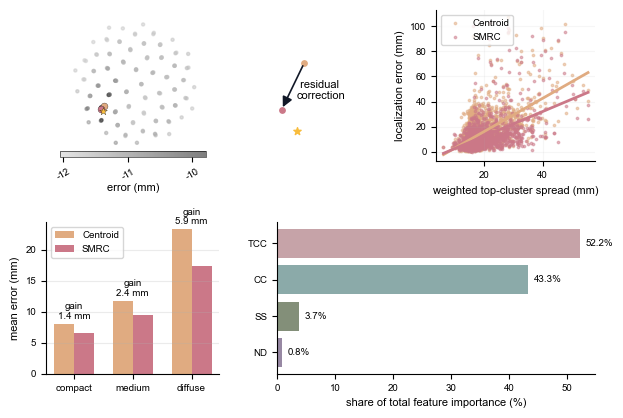

In [13]:
# fig7 mechanism
diff_idx = rep_ood

fig = plt.figure(figsize=(180 * MM, 120 * MM))

gs = GridSpec(2,3, figure=fig, width_ratios=[1.2,0.7,1.1], height_ratios=[1,1], wspace=0.4, hspace=0.4)

ax = fig.add_subplot(gs[0, 0], projection='3d', computed_zorder=False) 
score = arr['ood_score'][diff_idx]
sc = ax.scatter(candidates_mm[:,0], candidates_mm[:,1], candidates_mm[:,2], c=score, s=5, cmap=new_cmap, alpha=0.5, zorder=1)
top, cand, _, _, _ = top_cluster(candidates_mm,arr['ood_score'],arr['ood_top_idx'],diff_idx)
truth = arr['ood_truth'][diff_idx] * 1000.0
centroid_pred = arr['ood_centroid'][diff_idx] * 1000.0
geo_pred = arr['ood_geomeg'][diff_idx] * 1000.0
ax.scatter(truth[0], truth[1], s=35, marker='*', color=COL['truth'], label='true', edgecolor='k', linewidth=0.2, zorder=105, depthshade=False ) 
ax.scatter(centroid_pred[0], centroid_pred[1], s=25, color=COL['centroid'], label='Centroid',edgecolor='k', linewidth=0.2, zorder=100, depthshade=False ) 
ax.scatter(geo_pred[0], geo_pred[1], s=25, color=COL['geomeg'], label='SMRC', edgecolor='k', linewidth=0.2, zorder=103, depthshade=False ) 
make_3d_compact(ax, np.vstack([ candidates_mm, truth[None, :], centroid_pred[None, :], geo_pred[None, :]]), elev=90, azim=-90, zoom=1.2) 
# Colorbar for score map 
cax = inset_axes( ax, width="96%", height="4%", loc="lower center", borderpad=0.4 ) 
cbar_axes.append(cax) 
cbar = fig.colorbar( sc, cax=cax, orientation="horizontal" ) 
style_horizontal_colorbar( cbar, label="error (mm)", tick_formatter=FuncFormatter(lambda x, pos: f"{x:.1f}") )

ax = fig.add_subplot(gs[0, 1])
score = arr['ood_score'][diff_idx]
# sc = ax.scatter(candidates_mm[:,0], candidates_mm[:,1], c=score, s=5, cmap=new_cmap, alpha=0.5)
top, cand, _, _, _ = top_cluster(candidates_mm,arr['ood_score'],arr['ood_top_idx'],diff_idx)
truth = arr['ood_truth'][diff_idx] * 1000.0
centroid_pred = arr['ood_centroid'][diff_idx] * 1000.0
geo_pred = arr['ood_geomeg'][diff_idx] * 1000.0
ax.scatter(truth[0], truth[1], s=30, marker='*', color=COL['truth'], label='true')
ax.scatter(centroid_pred[0], centroid_pred[1], s=15, color=COL['centroid'], label='Centroid')
ax.scatter(geo_pred[0], geo_pred[1], s=15, color=COL['geomeg'], label='SMRC')
ax.annotate('',xy=(geo_pred[0], geo_pred[1]),xytext=(centroid_pred[0], centroid_pred[1]),arrowprops=dict(arrowstyle='-|>', lw=1.2, color='#111827'))
ax.text((geo_pred[0] + centroid_pred[0]) / 2 + 0.5, (geo_pred[1] + centroid_pred[1]) / 2-1,' residual\ncorrection',fontsize=8, fontname='Arial'); 
ax.set_xlim([-38, -25])
ax.set_ylim([-32, -20])
ax.axis('off')

from scipy.stats import pearsonr
ax = fig.add_subplot(gs[0,2])
ax.scatter(cg['spread_mm'], cg['centroid_err_mm'], s=3, alpha=0.5, color=COL['centroid'], label='Centroid')
ax.scatter(cg['spread_mm'], cg['geomeg_err_mm'], s=3, alpha=0.5, color=COL['geomeg'], label='SMRC')
ax.set_xlabel('weighted top-cluster spread (mm)',fontsize=8, fontname='Arial'); 
ax.set_ylabel('localization error (mm)',fontsize=8, fontname='Arial'); 
ax.tick_params(axis='both', labelsize=7)
# ax.set_title('Diffuse score clusters are harder; SMRC reduces the penalty'); 
ax.grid(alpha=0.1)
for method, color in [('centroid_err_mm', COL['centroid']), ('geomeg_err_mm', COL['geomeg'])]:
    x = cg['spread_mm'].to_numpy(); y = cg[method].to_numpy()
    coef = np.polyfit(x, y, 1); xx = np.linspace(x.min(), x.max(), 100)
    # 输出回归系数
    print(f'{method} coef_0 (slope): {coef[0]:.4f}')
    print(f'{method} coef_1 (intercept): {coef[1]:.4f}')
    # 计算 r 值（皮尔逊相关系数）
    r, p = pearsonr(x, y)
    print(f'{method} r value: {r:.4f}, p value: {p:.4e}')
    ax.plot(xx, coef[0]*xx + coef[1], color=color, lw=2)
ax.legend(frameon=True, loc='upper left', prop=arial_font)


ax = fig.add_subplot(gs[1,0])
spread_means = cg.groupby('spread_bin', observed=False)[['centroid_err_mm','geomeg_err_mm']].mean().loc[['compact','medium','diffuse']]
x = np.arange(3); width = 0.34
ax.bar(x-width/2, spread_means['centroid_err_mm'], width=width, color=COL['centroid'], label='Centroid')
ax.bar(x+width/2, spread_means['geomeg_err_mm'], width=width, color=COL['geomeg'], label='SMRC')
labels = ['compact','medium','diffuse']
for i, lab in enumerate(labels):
    gain = spread_means.loc[lab,'centroid_err_mm'] - spread_means.loc[lab,'geomeg_err_mm']
    ax.text(i,max(spread_means.loc[lab]) + 0.5,f'gain\n{gain:.1f} mm',ha='center',va='bottom',fontsize=7,linespacing=1.1)
ax.set_xticks(x, labels); 
ax.set_ylabel('mean error (mm)',fontsize=8, fontname='Arial'); 
# ax.set_title('Residual learning matters most for diffuse local manifolds'); 
ax.legend(frameon=True, prop=arial_font)
ax.grid(axis='y', alpha=0.25)
ax.tick_params(axis='both', labelsize=7)

# ax = fig.add_subplot(gs[1, 1])
# gg = gimp.sort_values('importance')
# colors = ['#9788a3', '#838F79', '#8BAAA9', '#c6a3a8']
# bars = ax.bar(gg['group'],gg['fraction'] * 100,color=colors)
# ax.set_ylabel('share of total feature importance (%)',fontsize=8, fontname='Arial'); 
# # ax.set_title('What the learner actually uses')
# for bar, v in zip(bars, gg['fraction'] * 100):
#     ax.text(bar.get_x()+bar.get_width()/2, v+1, f'{v:.1f}%', ha='center', va='bottom',fontsize=7)
# ax.tick_params(axis='x', rotation=30)
# ax.tick_params(axis='both', labelsize=7)


ax = fig.add_subplot(gs[1, 1:3])
label_map = {
    'top_candidate_coords': 'TCC',
    'centroid_coords': 'CC',
    'top_score_stats': 'SS',
    'nuisance': 'ND'
}
gg = gimp.sort_values('importance').copy()
gg['group_short'] = gg['group'].map(label_map).fillna(gg['group'])
ax.barh(gg['group_short'],gg['fraction'] * 100,
    color=['#9788a3', '#838F79', '#8BAAA9', '#c6a3a8'])
ax.set_xlabel('share of total feature importance (%)', fontsize=8, fontname='Arial')
ax.tick_params(axis='both', labelsize=7)
for i, v in enumerate(gg['fraction'] * 100):
    ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=7)
    

fig.savefig(FIGS / 'fig7_mechanism.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)

[np.float64(9.182220107306682), np.float64(10.800511047477494), np.float64(13.346237247563089)]
[np.float64(12.746324575249378), np.float64(13.870612254811942), np.float64(16.439770511413432)]
[np.float64(20.425110632555143), np.float64(23.118974962726238), np.float64(28.32075366076408)]


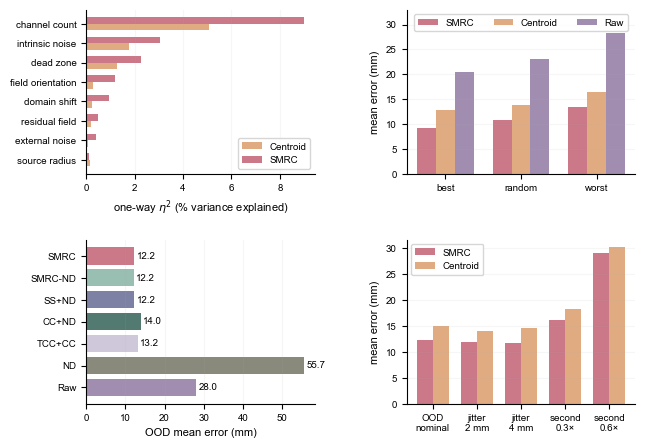

In [12]:
# fig8 error sources
fig = plt.figure(figsize=(180 * MM, 130 * MM))
gs = GridSpec(2,2, figure=fig, width_ratios=[1, 1], height_ratios=[1, 1], wspace=0.4, hspace=0.4)

ax = fig.add_subplot(gs[0,0])
eta_piv = eta[eta['method'].isin(['geomeg','centroid'])].pivot(index='factor', columns='method', values='eta_sq')
fac_order = eta_piv.max(axis=1).sort_values().index.tolist()
y = np.arange(len(fac_order))
ax.barh(y-0.17, eta_piv.loc[fac_order,'centroid']*100, height=0.34, color=COL['centroid'], label='Centroid')
ax.barh(y+0.17, eta_piv.loc[fac_order,'geomeg']*100, height=0.34, color=COL['geomeg'], label='SMRC')
ax.set_yticks(y, [f.replace('_',' ') for f in fac_order]); 
ax.set_xlabel(r'one-way $\eta^2$ (% variance explained)', fontsize=8, fontname='Arial')
# ax.set_title('Which nuisance factors drive the error most?'); 
ax.legend(frameon=True, loc='lower right', prop=arial_font)
ax.tick_params(axis='both', labelsize=7)
ax.grid(axis='x', alpha=0.1); 

ax = fig.add_subplot(gs[0,1])
dead_order = ['best','random','worst']
all_df = pd.concat([df_iid, df_ood], ignore_index=True)
geo_vals = [all_df[all_df['dead_mode']==d]['geomeg_err_mm'].mean() for d in dead_order]
print(geo_vals)
cent_vals = [all_df[all_df['dead_mode']==d]['centroid_err_mm'].mean() for d in dead_order]
print(cent_vals)
raw_vals = [all_df[all_df['dead_mode']==d]['raw_err_mm'].mean() for d in dead_order]
print(raw_vals)
x = np.arange(3); width=0.25
ax.bar(x-width, geo_vals, width=width, color=COL['geomeg'], label='SMRC')
ax.bar(x, cent_vals, width=width, color=COL['centroid'], label='Centroid')
ax.bar(x+width, raw_vals, width=width, color=COL['raw'], label='Raw')
ax.set_xticks(x, dead_order); 
ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
ax.set_ylim([0,33])
# ax.set_title('Dead-zone degradation'); 
ax.grid(axis='y', alpha=0.1)
ax.legend(frameon=True, loc='upper center', prop=arial_font, ncol=3)
ax.tick_params(axis='both', labelsize=7)

ax = fig.add_subplot(gs[1,0])
abood = ablation[ablation['split']=='OOD'].set_index('method').loc[['geomeg','no_nuis','scores_nuis','cent_only','coords_cent','nuis_only','raw']]
labels = ['SMRC','SMRC-ND','SS+ND','CC+ND','TCC+CC','ND','Raw']
vals = abood['mean_mm'].to_numpy()
colors = [COL['geomeg'],COL['no_nuis'],COL['scores_nuis'],COL['cent_only'],COL['coords_cent'],COL['nuis_only'],COL['raw']]
ax.barh(labels[::-1], vals[::-1], color=colors[::-1]); 
ax.set_xlabel('OOD mean error (mm)', fontsize=8, fontname='Arial')
# ax.set_title('OOD robustness comes from representation, not tree depth')
ax.tick_params(axis='both', labelsize=7)
ax.grid(axis='x', alpha=0.1); 
for i, v in enumerate(vals[::-1]):
    ax.text(v+0.6, i, f'{v:.1f}', va='center', fontsize=7)

# ax = fig.add_subplot(gs[2,0])
# all_df['count_bin'] = all_df['count'].astype(int).astype(str)
# counts = ['16','32','64']
# geo = [all_df[all_df['count_bin']==c]['geomeg_err_mm'].mean() for c in counts]
# cent = [all_df[all_df['count_bin']==c]['centroid_err_mm'].mean() for c in counts]
# rawm = [all_df[all_df['count_bin']==c]['raw_err_mm'].mean() for c in counts]
# ax.plot([16,32,64], geo, marker='o', color=COL['geomeg'], markersize=3, lw=1.2, label='SMRC')
# ax.plot([16,32,64], cent, marker='o', color=COL['centroid'], markersize=3, lw=1.2, label='Centroid')
# ax.plot([16,32,64], rawm, marker='o', color=COL['raw'], markersize=3, lw=1.2, label='Raw')
# ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
# ax.set_xlabel('active channels', fontsize=8, fontname='Arial'); 
# # ax.set_title('Channel count is the dominant design variable')
# ax.grid(alpha=0.1); 
# ax.legend(frameon=True, loc='lower center', prop=arial_font, ncol=3)
# ax.tick_params(axis='both', labelsize=7)
# ax.set_xticks([16, 32, 64])
# ax.set_ylim([0, 32])




ax = fig.add_subplot(gs[1,1])
scen_order = ['OOD_nominal','OOD_sensor_jitter_2mm','OOD_sensor_jitter_4mm','OOD_two_source_0p3','OOD_two_source_0p6']
labels = ['OOD\nnominal','jitter\n2 mm','jitter\n4 mm','second\n0.3×','second\n0.6×']
geo = stress[stress['method']=='geomeg'].set_index('scenario').loc[scen_order]['mean_mm'].to_numpy()
cent = stress[stress['method']=='centroid'].set_index('scenario').loc[scen_order]['mean_mm'].to_numpy()
x = np.arange(len(labels)); width=0.36
ax.bar(x-width/2, geo, width=width, color=COL['geomeg'], label='SMRC')
ax.bar(x+width/2, cent, width=width, color=COL['centroid'], label='Centroid')
ax.set_xticks(x, labels); 
ax.set_ylabel('mean error (mm)', fontsize=8, fontname='Arial')
# ax.set_title('Boundary conditions beyond the main benchmark'); 
ax.grid(axis='y', alpha=0.1); 
ax.legend(frameon=True, loc='upper left', prop=arial_font)
ax.tick_params(axis='both', labelsize=7)
# ax.tick_params(axis='x',rotation=30)
# for i, val in enumerate(geo):
#     ax.text(i-width/2, val+0.7, f'{val:.1f}', ha='center', fontsize=7)

fig.savefig(FIGS / 'fig8_error_sources.pdf', bbox_inches='tight')
plt.show()
plt.close(fig)


55